In [1]:
%matplotlib widget
# Add the directory containing the package to sys.path
import sys, os
package_dir = os.path.abspath("C:/Users/froll/Documents/Labo/Projets/Outils/swd")
if package_dir not in sys.path:
    sys.path.insert(0, package_dir)
    
from swd import spherical_processing as sp
import importlib

import numpy as np
from numpy import pi
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings("ignore")
from tqdm.auto import tqdm
np.set_printoptions(precision=2, suppress=True)

# Enable LaTeX rendering
plt.rc('text', usetex=True)
# Improve resolution
plt.rcParams['figure.dpi'] = 150
plt.rcParams['savefig.dpi'] = 300

# Import utils_SH_selection
scripts_dir = os.path.abspath("C:/Users/froll/Documents/Labo/Projets/Violon/scripts")
if scripts_dir not in sys.path:
    sys.path.insert(0, scripts_dir)

import utils_SH_selection
importlib.reload(utils_SH_selection)

<module 'utils_SH_selection' from 'C:\\Users\\froll\\Documents\\Labo\\Projets\\Violon\\scripts\\utils_SH_selection.py'>

In [2]:
#Vitesse du son au moment de la mesure, dependant de la temperature:
Tc = 21.5 
C = np.sqrt( 1.4 * 287 *(Tc + 273) )
Path = './'
NbMems = 256
NbViolTot = 6
NbViol = 1

NumViolon = np.load('./../results/NumViolon.npz')['NumViolon']
XYZViolins = np.load('./../results/XYZViolinsAligned.npy')

NbMics = 256
NbSrcs = XYZViolins.shape[0] - NbMics

XYZHammerImpact = XYZViolins[NbSrcs-1]
XYZ = XYZViolins-XYZHammerImpact
XYZs = XYZ[:NbSrcs-1]
XYZm = XYZ[NbSrcs:]
XYZHammerImpact = XYZ[NbSrcs-1]

Rm = np.linalg.norm(XYZm,axis=1)
Rmin = np.min(Rm)

### Array Quality Estimation

In [3]:
from ArrayPerfs import *
print(process_array_quality(XYZm, 1000))

Max Order (N): 15
Condition Number: 4.28e+11
WNG (dB): -110.77
Directivity Index (dB): 24.08
Robustness: Low


In [4]:
Pm = np.load('./../results/ViolinsFRFsAndRIs.npz')['Hhm']
frq = np.load('./../results/ViolinsFRFsAndRIs.npz')['frq']

MAX_ORDER = 15
NbSHMax = (MAX_ORDER+1)**2

frqmin = 100
frqMax = 12500

iBand = np.where((frq>=frqmin) & (frq<=frqMax))[0]
Band = frq[iBand]

Dyn = 36
CyclicScale = 'icefire' #edge, icefire, phase, hsv
RealScale = 'seismic'
Magnitudescale = 'inferno'

## Process optimal $\lambda$ and SH truncation order at all frequencies for each Violin

### Mathematical Description of the Optimal $C_{mn}$ Process

The acoustic pressure $P(\mathbf{r}, \omega)$ measured at $M$ microphone positions can be expanded into a set of Spherical Harmonics (SH) up to a truncation order $N$:
$$ \mathbf{P} \approx \mathbf{H}_N \mathbf{C}_N $$
where $\mathbf{P} \in \mathbb{C}^{M \times 1}$ is the measured pressure vector, $\mathbf{H}_N \in \mathbb{C}^{M \times (N+1)^2}$ is the transfer matrix (Spherical Wave basis), and $\mathbf{C}_N \in \mathbb{C}^{(N+1)^2 \times 1}$ contains the unknown SH coefficients.

#### 1. Regularized Inverse Problem
Due to the ill-posed nature of the problem (especially at low frequencies or high truncation orders), we use Tikhonov regularization to estimate the coefficients against measurement noise and ill-conditioning:
$$ \mathbf{C}_N(\lambda) = \arg\min_{\mathbf{C}} \left( ||\mathbf{P}_{meas} - \mathbf{H}_N \mathbf{C}||_2^2 + \lambda ||\mathbf{C}||_2^2 \right) $$
where $\lambda$ is the regularization parameter.

#### 2. K-Fold Cross-Validation
To select the optimal pair $(N_{opt}, \lambda_{opt})$ that generalizes well and avoids spatial overfitting, a $K$-fold Cross-Validation (CV) is performed:
1. The $M$ microphones are randomly partitioned into $K$ disjoint validation sets $\mathcal{V}_k$.
2. For each fold $k$, the remaining microphones form the interpolation set $\mathcal{I}_k$.
3. The coefficients $\mathbf{C}_N^{(k)}(\lambda)$ are estimated using only the interpolation set:
   $$ \mathbf{C}_N^{(k)}(\lambda) = (\mathbf{H}_{\mathcal{I}_k}^H \mathbf{H}_{\mathcal{I}_k} + \lambda \mathbf{I})^{-1} \mathbf{H}_{\mathcal{I}_k}^H \mathbf{P}_{\mathcal{I}_k} $$
4. The pressure is then predicted at the validation points:
   $$ \mathbf{P}_{rec}^{(k)} = \mathbf{H}_{\mathcal{V}_k} \mathbf{C}_N^{(k)}(\lambda) $$
5. The overall Relative Reconstruction Error $\mathcal{L}(N, \lambda)$ is computed across all folds by comparing predicted and measured validation pressures.

#### 3. Optimal Parameter Selection
We select parameters that produce minimal reconstruction error while prioritizing solutions with better matrix conditioning. The condition number of the transfer matrix $\kappa(\mathbf{H}_N)$ dictates the noise amplification.
The optimal parameters are selected by:
1. Finding the minimum CV error: $\mathcal{L}_{min} = \min_{N, \lambda} \mathcal{L}(N, \lambda)$
2. Defining a subset of acceptable parameters that yield an error close to the minimum (within a tolerance threshold $\epsilon$, e.g., $\epsilon = 0.05$):
   $$ \mathcal{S}_{accept} = \{ (N, \lambda) \mid \mathcal{L}(N, \lambda) \le \mathcal{L}_{min} + \epsilon \} $$
3. Among this subset of valid models, selecting the one that minimizes the condition number $\kappa(\mathbf{H}_N)$ to guarantee maximum robustness:
   $$ (N_{opt}, \lambda_{opt}) = \arg\min_{(N, \lambda) \in \mathcal{S}_{accept}} \kappa(\mathbf{H}_N) $$

This cross-validation procedure provides the most stable, parsimonious Spherical Harmonic expansion capable of accurately reconstructing the sound field.

In [ ]:
Process_HmaxEtKappa = False # Set to False to load previously computed parameters instead of re-computing Hmax and Kappa

from joblib import Parallel, delayed

if Process_HmaxEtKappa:
    H_max = sp.compute_SphericalWavesbasis_origin_to_field(XYZm, Band, MAX_ORDER, SH_center=np.array([0,0,0]))
    freqs = list(Band)
    Nfreqs = len(freqs)
    kvect = 2 * np.pi * np.array(freqs) / C

    TrO = np.arange(MAX_ORDER + 1)
    NTrO = len(TrO)
    
    def compute_freq_cond(H_freq, TrO_array):
        return [np.linalg.cond(H_freq[:, :(NSHana + 1)**2]) for NSHana in TrO_array]

    results = Parallel(n_jobs=-2)(
        delayed(compute_freq_cond)(H_max[:, :, ifreq], TrO)
        for ifreq in tqdm(range(Nfreqs), desc="Frequencies (Parallel)")
    )
    Kappa = np.array(results).T
    
    np.savez('./../results/ViolinHmaxEtKappa.npz', H_max=H_max, KappaH_max=KappaH_max, freqs=freqs, TrO=TrO)
else :
    data = np.load('./../results/ViolinHmaxEtKappa.npz')
    H_max = data['H_max']
    Kappa= data['KappaH_max']
    freqs = data['freqs']
    TrO = data['TrO']
    Nfreqs = len(freqs)
    NTrO = len(TrO)
    kvect = 2 * np.pi * np.array(freqs) / C
    del data

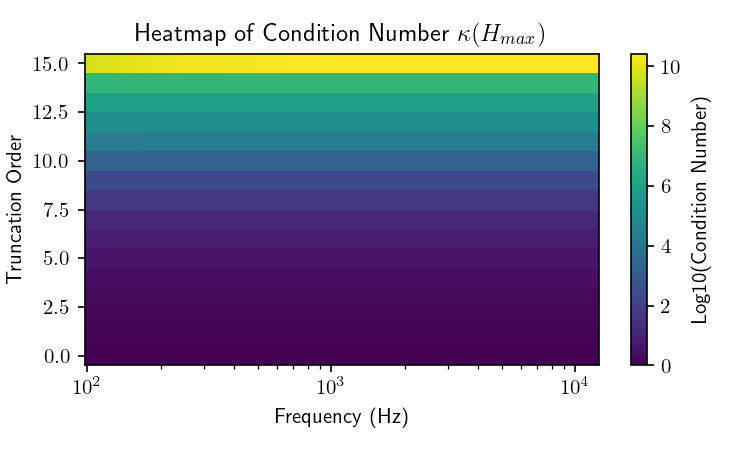

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Plotting the heatmap of KappaH_max in log scale to better visualize the condition numbers
plt.figure(figsize=(5, 3))
# Using log10 as condition numbers can vary by orders of magnitude
c = plt.pcolormesh(freqs, TrO, np.log10(Kappa), cmap='viridis', shading='nearest')
plt.colorbar(c, label='Log10(Condition Number)')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Truncation Order')
plt.title('Heatmap of Condition Number $\kappa(H_{max})$')
plt.xscale('log')
plt.tight_layout()
plt.show()

In [ ]:
Process_Opt = True # Set to False to load previously computed parameters instead of re-optimizing
from joblib import Parallel, delayed

LbdaList = np.logspace(-8, 0, 50)
NLbda = len(LbdaList)

def optimize_frequency(ifreq, Pmeas_f_all, H_max_f_all, kappa_f_all, TrO, LbdaList, Vsets, NbMics):
    # Extract frequency slices to minimize memory overhead per worker
    Pmeas_f = Pmeas_f_all[:, ifreq:ifreq+1]
    H_max_f = H_max_f_all[:, :, ifreq:ifreq+1]
    kappa_f = kappa_f_all[:, ifreq:ifreq+1]
    
    Lerr = np.empty((len(TrO), len(LbdaList)), dtype=float)
    
    for iTrO, NSHana in enumerate(TrO):
        Hfull_f = H_max_f[:, :(NSHana + 1)**2, :]
        
        for ilbda, lbda in enumerate(LbdaList):
            P_rec = np.empty((NbMics, 1), dtype=complex)
            
            for iset in range(len(Vsets)):
                ival = Vsets[iset]
                iint = [ind for ind in np.arange(NbMics) if ind not in ival]
                
                H_int = Hfull_f[iint, :, :]
                H_val = Hfull_f[ival, :, :]
                P_meas_int = Pmeas_f[iint, :]
                
                cmn = sp.compute_SHcoefs(P_meas_int, H_int, lambda_reg=lbda)
                P_rec[ival, 0] = (H_val[:, :, 0] @ cmn).squeeze()
            
            # Compute cross-validation error
            Lerr[iTrO, ilbda] = np.linalg.norm(Pmeas_f[:, 0] - P_rec[:, 0]) / np.linalg.norm(Pmeas_f[:, 0])

    threshold_min = 5e-2
    Lmin = np.min(Lerr)
    
    # Find combinations within acceptable threshold
    valid_indices = np.where(Lerr < Lmin + threshold_min)
    valid_N_idx = valid_indices[0]
    valid_lambda_idx = valid_indices[1]
    
    # Select the valid setup with minimal condition number (kappa)
    valid_kappas = kappa_f[valid_N_idx]
    opt_idx_in_valid = np.argmin(valid_kappas)
    
    opt_N_idx = valid_N_idx[opt_idx_in_valid]
    opt_lambda_idx = valid_lambda_idx[opt_idx_in_valid]
    
    return {
        'ifreq': ifreq,
        'Torder': TrO[opt_N_idx],
        'Lambda': LbdaList[opt_lambda_idx],
        'Kappa': kappa_f[opt_N_idx],
        'L_opt': Lerr[opt_N_idx, opt_lambda_idx]
    }

if Process_Opt:
    # Initialize storage
    Lambdas = {v: np.zeros(Nfreqs) for v in range(NbViol)}
    Torders = {v: np.zeros(Nfreqs, dtype=int) for v in range(NbViol)}
    Kappas = {v: np.zeros(Nfreqs) for v in range(NbViol)}
    L_opt = {v: np.zeros(Nfreqs) for v in range(NbViol)}

    print(f"Optimizing orders for {NbViol} violins over {Nfreqs} frequencies...")

    Nv_sets = 5
    NbMics = NbMics
    NbMicsv = NbMics // Nv_sets
    Vsets = [np.random.choice(NbMics, size=NbMicsv, replace=False) for _ in range(Nv_sets)]  

    for v in tqdm(range(NbViol), desc="Violins"):
        Pmeas = Pm[v, iBand, :].T # shape: (Narray, Nfreq)

        results = Parallel(n_jobs=-2)(
            delayed(optimize_frequency)(ifreq, Pmeas, H_max, Kappa, TrO, LbdaList, Vsets, NbMics)
            for ifreq in tqdm(range(Nfreqs), desc="Frequencies (Parallel)", leave=False)
        )
        
        # Populate arrays with parallel results
        for res in results:
            idx = res['ifreq']
            Torders[v][idx] = res['Torder']
            Lambdas[v][idx] = res['Lambda']
            Kappas[v][idx] = res['Kappa'][0] if isinstance(res['Kappa'], (list, np.ndarray)) else res['Kappa']
            L_opt[v][idx] = res['L_opt']

    np.savez(f'./../results/Optimal_Lambdas_Orders_O{MAX_ORDER}.npz', 
             orders=Torders, 
             lambdas=Lambdas, 
             kappas=Kappas,
             freqs=freqs)
    print(f"Saved optimization parameters to ./../results/Optimal_Lambdas_Orders_O{MAX_ORDER}.npz")
else:
    data = np.load(f'./../results/Optimal_Lambdas_Orders_O{MAX_ORDER}.npz', allow_pickle=True)
    freqs = data['freqs']
    Lambdas = data['lambdas'].item()
    Torders = data['orders'].item()
    Kappas = data['kappas'].item() if 'kappas' in data else {v: np.zeros(Nfreqs) for v in range(NbViol)}
    print(f"Loaded parameters from ./../results/Optimal_Lambdas_Orders_O{MAX_ORDER}.npz")

fig, axs = plt.subplots(3, 1, figsize=(8, 9), sharex=True)

viol_names = NumViolon if 'NumViolon' in locals() else [f"Violin {v}" for v in range(NbViol)]
cm_plot = plt.get_cmap('gist_rainbow') 
colors = [cm_plot(1.*i/NbViol) for i in range(NbViol)]

for v in range(NbViol):
    lbl = viol_names[v] if v < len(viol_names) else f"Violin {v}"
    axs[0].semilogx(freqs, Torders[v], '-', linewidth=1.5, label=lbl, color=colors[v])
    axs[1].loglog(freqs, Kappas[v], '-', linewidth=1.5, label=lbl, color=colors[v])
    axs[2].loglog(freqs, Lambdas[v], '-', linewidth=1.5, label=lbl, color=colors[v])

axs[0].set_ylabel('Optimal SH Order')
axs[0].set_title('Optimization Parameters vs Frequency')
axs[0].grid(True, which='both', alpha=0.8)
axs[0].set_yticks(np.arange(0, MAX_ORDER + 2, 1))

axs[1].set_ylabel(r'Condition Number $\kappa$')
axs[1].grid(True, which='both', alpha=0.8)

axs[2].set_xlim(frqmin, frqMax)
axs[2].set_xlabel('Frequency (Hz)')
axs[2].set_ylabel(r'Regularization $\lambda$')
axs[2].grid(True, which='both', alpha=0.8)

axs[0].legend(ncol=2, fontsize='small')

plt.tight_layout()
plt.show()

Optimizing orders for 1 violins over 2481 frequencies...


Violins:   0%|          | 0/1 [00:00<?, ?it/s]

Frequencies (Parallel):   0%|          | 0/2481 [00:00<?, ?it/s]

In [ ]:

print(f"\nComputing Cmn for all {NbViol} violins using compute_SHcoefs_VariableLbdas...")

NbSH_max = (MAX_ORDER + 1)**2
Cmn_all = np.zeros((NbViol, NbSH_max, len(freqs)), dtype=complex)

kvect = 2 * np.pi * np.array(freqs) / C
# Compute basis up to MAX_ORDER for all frequencies at once
H_max = sp.compute_SphericalWavesbasis_origin_to_field(
    XYZm, kvect, MAX_ORDER, SH_center=np.array([0,0,0])
)

for v in tqdm(range(NbViol), desc="Processing violins"):
    order_v = np.array(Torders[v], dtype=int)
    lam_v = np.array(Lambdas[v])
    
    # pmeas should be (N_fieldpoints, N_k)
    pmeas_v = Pm[v, iBand, :].T 
    
    # Use swd2 dedicated function
    c_coeffs = sp.compute_SHcoefs_VariableLbdas(
        pmeas=pmeas_v, 
        H=H_max, 
        N_SH_vect=order_v, 
        lambda_reg=lam_v
    )
    
    Cmn_all[v, :, :] = c_coeffs

# Update Globals for consistency (Set Cmn0 to the selected violin NumV)
NumV = 1
Cmn0 = Cmn_all[NumV]
OSH = MAX_ORDER
O_SH_vect = np.array(Torders[NumV])
print(f"Cmn computation complete. Shape: {Cmn_all.shape}")

In [ ]:
np.savez('./../results/CmnO'+str(MAX_ORDER)+'_Optimization_Results.npz', 
         orders=Torders, 
         lambdas=Lambdas, 
         freqs=freqs,
         Cmn_all=Cmn_all)
print("Saved detailed optimization results to ./../results/CmnO"+str(MAX_ORDER)+"_Optimization_Results.npz")